# Pairs — Kiểm tra dữ liệu đã tiền xử lý

Notebook này kiểm tra và trực quan hoá dữ liệu cặp `(ảnh, caption)` đã được tiền xử lý:

1. Thống kê cặp theo split (JSON cache)
2. Mẫu cặp thực tế — ảnh + caption
3. Đặc trưng HDF5 — hình dạng và phân phối
4. Minh hoạ cơ chế sinh nhãn matched / unmatched


In [1]:
import os, sys, json
from pathlib import Path

PROJECT_ROOT = Path().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

try:
    from dotenv import load_dotenv

    load_dotenv(PROJECT_ROOT / ".env.mac", override=True)
    load_dotenv(PROJECT_ROOT / ".env", override=False)
except ImportError:
    pass

from utils.env_utils import get_data_root

DATA_ROOT = get_data_root()
HDF5_DIR = DATA_ROOT / "processed_data" / "hdf5"
PAIRS_DIR = HDF5_DIR / "pairs"
JPG_DIR = DATA_ROOT / "data" / "jpg"

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"DATA_ROOT    : {DATA_ROOT}")
print(f"PAIRS_DIR    : {PAIRS_DIR}  exists={PAIRS_DIR.exists()}")
print(f"HDF5_DIR     : {HDF5_DIR}   exists={HDF5_DIR.exists()}")

PROJECT_ROOT : /Users/haila/My File/projects/fake-new-detection
DATA_ROOT    : /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis
PAIRS_DIR    : /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/processed_data/hdf5/pairs  exists=True
HDF5_DIR     : /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/processed_data/hdf5   exists=True


---

## 1. Thống kê cặp theo split


Split       Pairs    Articles (unique)   Avg caps/article
------------------------------------------------------------
train       6,724                3,304               2.04
dev           862                  468               1.84
test        2,053                  967               2.12


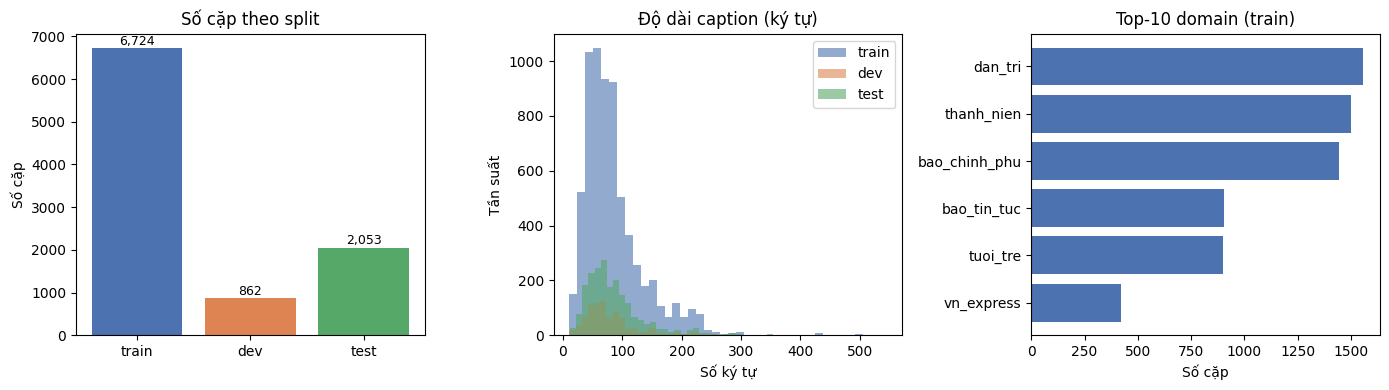

In [2]:
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams["font.family"] = "DejaVu Sans"

SPLITS = ["train", "dev", "test"]

pairs = {}
for split in SPLITS:
    p = PAIRS_DIR / f"pairs_{split}.json"
    pairs[split] = json.load(open(p, encoding="utf-8"))

# ── Summary table ──────────────────────────────────────────────────────────
print(f"{'Split':<8} {'Pairs':>8} {'Articles (unique)':>20} {'Avg caps/article':>18}")
print("-" * 60)
for s in SPLITS:
    n = len(pairs[s])
    arts = len({p["article_idx"] for p in pairs[s]})
    avg = n / arts if arts else 0
    print(f"{s:<8} {n:>8,} {arts:>20,} {avg:>18.2f}")

# ── Bar chart ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1) Pair counts
counts = [len(pairs[s]) for s in SPLITS]
axes[0].bar(SPLITS, counts, color=["#4C72B0", "#DD8452", "#55A868"])
axes[0].set_title("Số cặp theo split")
axes[0].set_ylabel("Số cặp")
for i, v in enumerate(counts):
    axes[0].text(i, v + 80, f"{v:,}", ha="center", fontsize=9)

# 2) Caption length distribution (char count)
for s, color in zip(SPLITS, ["#4C72B0", "#DD8452", "#55A868"]):
    lengths = [len(p["caption"]) for p in pairs[s]]
    axes[1].hist(lengths, bins=40, alpha=0.6, label=s, color=color)
axes[1].set_title("Độ dài caption (ký tự)")
axes[1].set_xlabel("Số ký tự")
axes[1].set_ylabel("Tần suất")
axes[1].legend()

# 3) Top-10 domains (train)
domains = [p["folder_path"].split("/")[0] for p in pairs["train"]]
top10 = Counter(domains).most_common(10)
dom_names, dom_counts = zip(*top10)
axes[2].barh(dom_names[::-1], dom_counts[::-1], color="#4C72B0")
axes[2].set_title("Top-10 domain (train)")
axes[2].set_xlabel("Số cặp")

plt.tight_layout()
plt.show()

---

## 2. Mẫu cặp thực tế — ảnh + caption


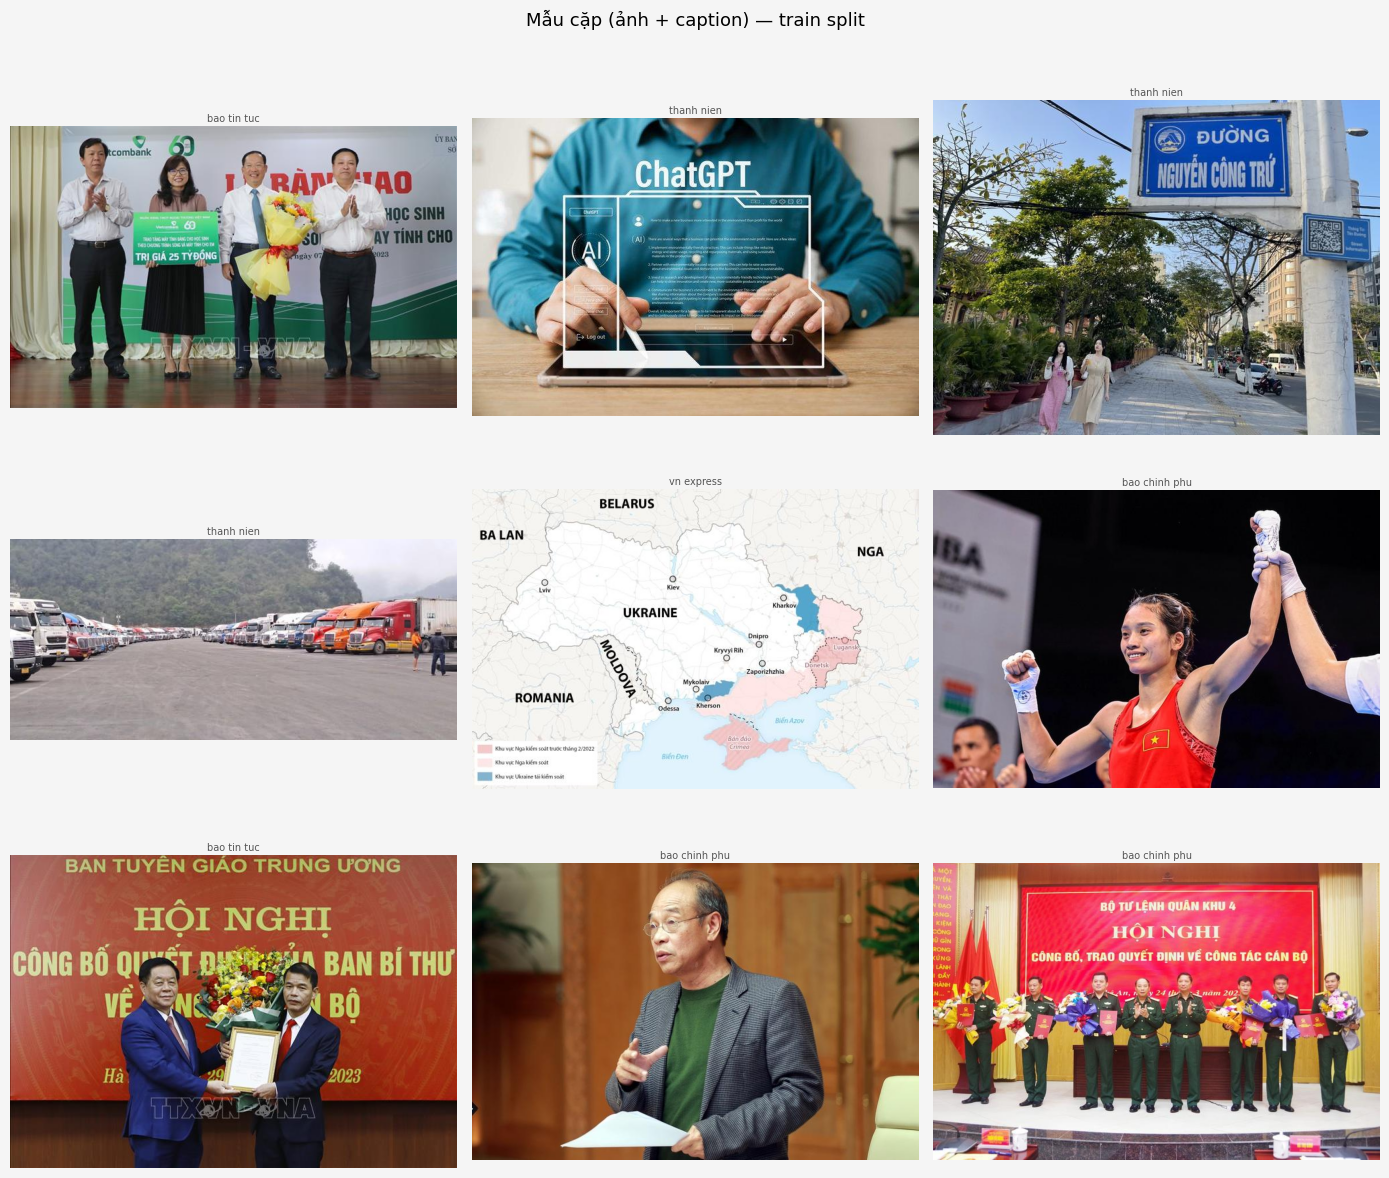

In [3]:
import textwrap
import random
from PIL import Image

random.seed(42)

GRID_ROWS, GRID_COLS = 3, 3
N = GRID_ROWS * GRID_COLS

# Sample from train — keep only pairs whose image file exists
candidates = [p for p in pairs["train"] if Path(p["image_path"]).exists()]
samples = random.sample(candidates, min(N, len(candidates)))

fig, axes = plt.subplots(GRID_ROWS, GRID_COLS, figsize=(14, 12))
fig.patch.set_facecolor("#f5f5f5")

for ax, pair in zip(axes.flat, samples):
    img = Image.open(pair["image_path"]).convert("RGB")
    ax.imshow(img)
    ax.axis("off")

    caption = pair["caption"]
    wrapped = "\n".join(textwrap.wrap(caption, width=30)[:3])
    if len(textwrap.wrap(caption, width=30)) > 3:
        wrapped += "…"

    domain = pair["folder_path"].split("/")[0].replace("_", " ")
    ax.set_xlabel(wrapped, fontsize=7.5, wrap=False, labelpad=4, color="#222")
    ax.set_title(domain, fontsize=7, color="#555", pad=3)

plt.suptitle("Mẫu cặp (ảnh + caption) — train split", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---

## 3. HDF5 — Đặc trưng đã trích xuất

Mỗi file HDF5 chứa:

| Dataset            | Shape           | Nội dung                                                |
| ------------------ | --------------- | ------------------------------------------------------- |
| `caption_features` | `(N, 128, 768)` | PhoBERT embeddings — mỗi token 768-D, tối đa 128 tokens |
| `image_features`   | `(N, 2048)`     | ResNet50 global average-pool — 1 vector 2048-D / ảnh    |
| `article_ids`      | `(N,)`          | ID bài báo gốc (dùng để tránh negative cùng bài)        |
| `image_paths`      | `(N,)`          | Đường dẫn file JPG                                      |
| `folder_paths`     | `(N,)`          | Đường dẫn tương đối                                     |


In [ ]:
import h5py

hdf5 = {}
for split in SPLITS:
    hdf5[split] = h5py.File(HDF5_DIR / f"coolant_{split}.h5", "r")

# ── Shape summary ──────────────────────────────────────────────────────────
print(f"{'Split':<8} {'caption_features':>22} {'image_features':>18}")
print("-" * 52)
for s in SPLITS:
    cf = hdf5[s]["caption_features"].shape
    im = hdf5[s]["image_features"].shape
    print(f"{s:<8} {str(cf):>22} {str(im):>18}")

# ── Image feature norm distribution ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for s, color in zip(SPLITS, ["#4C72B0", "#DD8452", "#55A868"]):
    img_feats = hdf5[s]["image_features"][:]  # (N, 2048)
    norms = np.linalg.norm(img_feats, axis=1)
    axes[0].hist(norms, bins=40, alpha=0.6, label=s, color=color)

axes[0].set_title("Image feature L2-norm (ResNet50)")
axes[0].set_xlabel("||f||₂")
axes[0].set_ylabel("Tần suất")
axes[0].legend()

# ── Caption effective token count ─────────────────────────────────────────
# Non-padding tokens: rows of caption_features whose L2-norm > threshold
THRESH = 0.01
for s, color in zip(SPLITS, ["#4C72B0", "#DD8452", "#55A868"]):
    cap_feats = hdf5[s]["caption_features"][:]  # (N, 128, 768)
    token_norms = np.linalg.norm(cap_feats, axis=2)  # (N, 128)
    eff_len = (token_norms > THRESH).sum(axis=1)  # (N,)
    axes[1].hist(eff_len, bins=40, alpha=0.6, label=s, color=color)

axes[1].set_title("Số token hữu hiệu / caption (PhoBERT)")
axes[1].set_xlabel("Số token (norm > 0.01)")
axes[1].set_ylabel("Tần suất")
axes[1].legend()

plt.tight_layout()
plt.show()

Split          caption_features     image_features
----------------------------------------------------
train          (6724, 128, 768)       (6724, 2048)
dev             (862, 128, 768)        (862, 2048)
test           (2053, 128, 768)       (2053, 2048)
